In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API key is set")
else:
    raise ValueError("Google API key is not set")

Google API key is set


In [3]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
   # other params...
)

try :
  print("Don't waste the tokens.")
except:
  print("Something went wrong")

Don't waste the tokens.


## First Graph

### Step-1: Define the Schema or State
Schema or State is what exactly you need to travel from one node to another node.
Schema is of two types
1.Light Weight Schema(No strict Rules)
2. Heavy Weight(Strict Rules)

In [4]:
from typing import TypedDict,List,Annotated
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List,add_messages]

### Step-2: Create The Node Functions

The state or schema is available for each function automatically by default. This variable will have the data type of the schema or state we defined

In [5]:
def welcome(state:graph_schema) -> graph_schema:
    curr_message=state['messages']

    response=model.invoke(curr_message).content

    state['messages'] = f"Your message was {curr_message}. Here's is my response: {response}"

    return state


### Step-3: Create The State Graph

In [6]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema) # Initialise the Graph with the schema as arguement

# START and END are two default nodesnodes 

#Adding Nodes
graph.add_node("welcome",welcome) # First Argument is node name and second argument is the function to be executed

#Adding Edges
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

### Step-4: Compile The Graph With Checkpoint

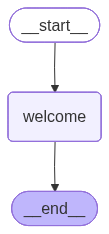

In [9]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

checkpoint=InMemorySaver()

memory_graph=graph.compile(checkpointer=checkpoint)  

# You could see errors with the below command
Image(memory_graph.get_graph().draw_mermaid_png())

#You can use the below command to see the graph withour errors(mermaid code)
# print(first_graph.get_graph().draw_mermaid())

### Step-5: Run The Graph With Config

In [ ]:
memory_graph.invoke(
    {"messages": "What is my name "},
    {'configurable':{'thread_id':'SVP'}}# This helps as a index or id in memory, we can retrive the previous context and answer based on this.
)

{'messages': [HumanMessage(content='My name is Sai Vinay', additional_kwargs={}, response_metadata={}, id='f54fa397-f434-4468-8373-5f9dfad28e80'),
  HumanMessage(content="Your message was [HumanMessage(content='My name is Sai Vinay', additional_kwargs={}, response_metadata={}, id='f54fa397-f434-4468-8373-5f9dfad28e80')]. Here's is my response: Hello Sai Vinay! It's nice to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={}, id='1088d4df-410c-4461-ba5e-1eaa47049c0a'),
  HumanMessage(content='What is my name ', additional_kwargs={}, response_metadata={}, id='a8150075-bc13-4f06-a9e1-68c7fd4b9090'),
  HumanMessage(content='Your message was [HumanMessage(content=\'My name is Sai Vinay\', additional_kwargs={}, response_metadata={}, id=\'f54fa397-f434-4468-8373-5f9dfad28e80\'), HumanMessage(content="Your message was [HumanMessage(content=\'My name is Sai Vinay\', additional_kwargs={}, response_metadata={}, id=\'f54fa397-f434-4468-8373-5f9dfad28e80\')]. Here\'s 